# Task 2: Forward Kinematics

## 2.1 Rotation Matrices

We need to send create a rotation matrix for each of the three axes (x, y, z). Implement the function `rotate_by_axis` in `utils/rotation.py`. Each function should take an angle in radians as input and return the corresponding 3x3 rotation matrix. See lecture slides for the formulas.

e.g.:
point = np.array([1, 0, 0]) --> rotate around z-axis by 90 degrees (π/2 radians) --> new point = np.array([0, 1, 0])

**To Do:**
- Implement the function `rotate_by_axis` in `utils/rotation.py`.

In [1]:
# ToDo: replace torch with any other autograd library you prefer
import torch
import numpy as np
p0 = torch.tensor([1, 0, 0], dtype=torch.float32)
axis = torch.tensor([0, 0, 1], dtype=torch.float32)
angle = torch.tensor(np.pi / 2, dtype=torch.float32)  # 90 degrees in radians

# Task: Implement the function rotate_by_axis in fk/rotation.py
from fk.rotation import rotate_by_axis
p_rotated, _ = rotate_by_axis(p0, axis, angle) # <-- Your implementation here
print("Original point:", p0)
print("Rotated point:", torch.round(p_rotated, decimals=4))
print('Expected output met:', torch.allclose(p_rotated, torch.tensor([0, 1, 0], dtype=torch.float32), atol=1e-4))  # Should be close to [0, 1, 0]

Original point: tensor([1., 0., 0.])
Rotated point: tensor([-0., 1., 0.])
Expected output met: True


/Users/markusgambietz/PhD/teaching/WS25/movement_analysis_sem/assignments/assignment_01_fk/fk/rotation.py:53: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1719361022956/work/aten/src/ATen/native/TensorShape.cpp:3679.)
  return torch.matmul(rotation_matrix, point.T).T, rotation_matrix


## 2.2 Multiple rotations

The function should be easy to use for multiple rotations. For example, if you want to rotate a point first around the x-axis by 30 degrees, then around the y-axis by 45 degrees, and finally around the z-axis by 60 degrees, you should be able to do something like this:

In [2]:
p0 = torch.tensor([0, -1, 0], dtype=torch.float32)
_, r1 = rotate_by_axis(p0, torch.tensor([1, 0, 0], dtype=torch.float32), torch.tensor(np.pi / 6, dtype=torch.float32))  # Rotate around x-axis by 30 degrees
_, r2 = rotate_by_axis(p0, torch.tensor([0, 1, 0], dtype=torch.float32), torch.tensor(np.pi / 4, dtype=torch.float32))  # Rotate around y-axis by 45 degrees
_, r3 = rotate_by_axis(p0, torch.tensor([0, 0, 1], dtype=torch.float32), torch.tensor(np.pi / 3, dtype=torch.float32))  # Rotate around z-axis by 60 degrees
r_final = r3 @ r2 @ r1  # We need to apply in reverse order for extrinsic rotations
p_rotated = torch.matmul(r_final, p0.T).T
print("Original point:", p0)
print("Rotated point after multiple rotations:", torch.round(p_rotated, decimals=4))
print("Expected output met:", torch.allclose(p_rotated, torch.tensor([0.5732, -0.7392, -0.3536], dtype=torch.float32), atol=1e-4))

Original point: tensor([ 0., -1.,  0.])
Rotated point after multiple rotations: tensor([ 0.5732, -0.7392, -0.3536])
Expected output met: True


**To Do:**
Implement `rotate_multi_axis` in `utils/rotation.py` that takes a point, rotation order and angles as input and returns the rotated point as well as the final rotation matrix. 

In [3]:
from fk.rotation import rotate_multi_axis
p0 = torch.tensor([0, -1, 0], dtype=torch.float32)
p_final, r_final = rotate_multi_axis(p0, ['x', 'y', 'z'], torch.tensor([np.pi / 6, np.pi / 4, np.pi / 3], dtype=torch.float32))  # Rotate around x by 30, y by 45, z by 60 degrees
print("Original point:", p0)
print("Rotated point using rotate_multi_axis:", torch.round(p_final, decimals=4))
print("Expected output met:", torch.allclose(p_final, torch.tensor([0.5732, -0.7392, -0.3536], dtype=torch.float32), atol=1e-4))

Original point: tensor([ 0., -1.,  0.])
Rotated point using rotate_multi_axis: tensor([ 0.5732, -0.7392, -0.3536])
Expected output met: True


## 2.4 Forward Kinematics

Now, we want to iterate over all joints of the human body model and apply the rotations to each joint based on the provided angles. Implement the function `forward_kinematics` in `fk/forward_kinematics.py`.
The function should take the following inputs:
- 'q': A ndarray of generalized coordinates (joint angles) of shape (N,).
- 'key': A list of joint names corresponding to the angles in 'q'.
- 'kintree': A dictionary of the kinematic tree as in `model/kintree.py`.

The function should return:
- 'joints': A dictionary where each key is a joint name and the value is a ndarray of shape (3,) representing the 3D position of the joint after applying the forward kinematics.
- 'markers': A dictionary where each key is a marker name and the value is a ndarray of shape (3,) representing the 3D position of the marker after applying the forward kinematics.

In [4]:
# Set up the data
from model.kintree import kintree
from fk.forward_kinematics import forward_kinematics
from utils.load_data import * 

q_all = load_kinematics_data()
marker_data = load_marker_data()
curr_frame = 3000
q = q_all.iloc[curr_frame,1:] # Exclude time column, 
markers = marker_data.iloc[curr_frame,2:] # Exclude time and frame column
key = list(q_all.columns[1:]) # Exclude time column

/Users/markusgambietz/PhD/teaching/WS25/movement_analysis_sem/assignments/assignment_01_fk/utils/load_data.py:6: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136) have mixed types. Specify dtype option on import or set low_memory=False.
  marker_data = pd.read_csv(file_path, sep='\t', skiprows=3)


**To Do:**

Now implement the function `forward_kinematics` in `fk/forward_kinematics.py`.

Frame Marker Error (RMSE): 31.460628811488007 mm


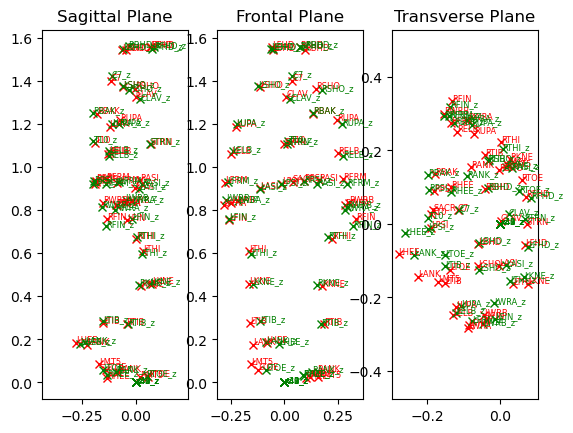

In [5]:
from utils import evaluate_marker_error, visualize_markers
joint_positions, marker_positions = forward_kinematics(q.values, key, kintree) # <-- Your implementation here
print("Frame Marker Error (RMSE):", evaluate_marker_error(marker_positions, markers)*1e3, "mm") 
visualize_markers(marker_positions, markers) # Visualize current frame

Even with a correct forward kinematics implementation, the marker error might still be quite high (> 30 mm). This is because the markers are experimental data (i.e. noisy) and the model is a simplified version of the actual scaled OpenSim model, where some joints have been removed or simplified. For frame 3000, my marker error is 31.46 mm. If your error is substantially higher, please check your implementation again.

At this point, all tests in `pytest tests.py` should pass, only the task of plotting a skeleton stick figure is still open. 

## 2.5 Plotting the Human Body Model

**To Do:**

Implement the function `get_connections` in `fk/forward_kinematics.py` that returns a list of tuples representing the connections between joints for plotting the skeleton. Each tuple should contain two joint names that are connected.



In [6]:
from fk.forward_kinematics import get_connections
joint_positions, marker_positions = forward_kinematics(q, key, kintree)
connections = get_connections(kintree, joint_positions) # <-- Your implementation here

/Users/markusgambietz/PhD/teaching/WS25/movement_analysis_sem/assignments/assignment_01_fk/fk/forward_kinematics.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  angle.append(q[key.index(joint_name)])
/Users/markusgambietz/PhD/teaching/WS25/movement_analysis_sem/assignments/assignment_01_fk/fk/forward_kinematics.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  translation += np.array(joint_data.get('axis'), dtype=np.float32) * q[key.index(joint_name)]
/Users/markusgambietz/PhD/teaching/WS25/movement_analysis_sem/assignments/assignment_01_fk/fk/forward_kinematics.py:70: FutureWarning: Series.__getitem__ treati

If the function is implemented correctly, you should be able to visualize the skeleton as follows (it may not be beautiful though):

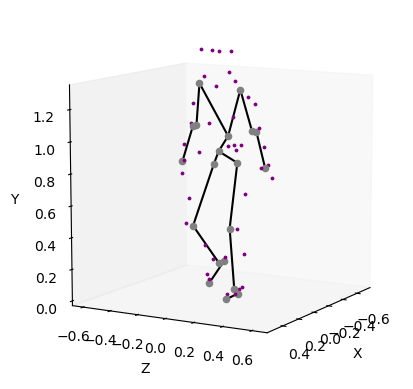

In [7]:
# Plot skeleton in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Plot joints
for _joint in joint_positions.values():
    ax.scatter(_joint[0], _joint[2], _joint[1], c='gray', s=20)
# Plot bones
for _bone in connections:
    ax.plot([_bone[0][0], _bone[1][0]], [_bone[0][2], _bone[1][2]], [_bone[0][1], _bone[1][1]], c='k')

for marker in marker_positions.values():
    ax.scatter(marker[0], marker[2], marker[1], c='purple', s=3)

ax.set_xlabel('X')
ax.set_zlabel('Y')
ax.set_ylabel('Z')
# Set equal aspect ratio
# create a cube to set the aspect ratio to equal
jps_ = np.vstack(list(joint_positions.values()))
max_range = np.array([jps_[:,0].max()-jps_[:,0].min(), 
                      jps_[:,1].max()-jps_[:,1].min(), 
                      jps_[:,2].max()-jps_[:,2].min()]).max() / 2.0
mid_point = np.array([ (jps_[:,0].max()+jps_[:,0].min()) * 0.5,
                       (jps_[:,1].max()+jps_[:,1].min()) * 0.5,
                       (jps_[:,2].max()+jps_[:,2].min()) * 0.5 ])
mid_x = mid_point[0]
mid_y = mid_point[1]
mid_z = mid_point[2]
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_zlim(mid_y - max_range, mid_y + max_range)
ax.set_ylim(mid_z - max_range, mid_z + max_range)
ax.set_box_aspect([1,1,1])
ax.view_init(elev=10., azim=30)
ax.grid(False)